<div style="text-align: center; font-family: 'Times New Roman', Times, serif;">

## Cubli Simulation

Coded by Benjamin Saunders

Based on *The Cubli: Modeling and Nonlinear Attitude Control Utilizing Quaternions* by Bobrow et. al.
</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## I. Dynamics

### Nonlinear EOMs

According to Eq. 77 the dynamics are given as
$$
\begin{equation}\tag{77}
\left\{
\begin{array}{lcl}
\dot{q} & = & \frac{1}{2}G^T(q)\vec{\omega}_c \\

\dot{\vec{\theta}}_w & = & \vec{\omega}_w \\

\dot{\vec{\omega}}_c & = & \bar{I}_c^{-1} (-\vec{\omega}_c \times (\bar{I}_c \vec{\omega}_c + \bar{I}_w\vec{\omega}_w) -\bar{m}_c g l (G(q) \Gamma q) \\
& & \quad - b (G(q) \Lambda q (G(q) \Lambda q)^T) \vec{\omega}_c + \vec{\tau}_f(\vec{\omega}_w) - \vec{\tau} + \vec{\tau}_d )\\

\dot{\vec{\omega}}_w & = & \bar{I}_w^{-1}(-\vec{\tau}_f(\vec{\omega}_w)+\vec{\tau})

\end{array}
\right.
\end{equation}
$$
</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

where, for reference, we define the quaternion product matrix, 
$$
\begin{equation}\tag{17}
G_{3\times 4}(q) = \begin{bmatrix}-q & q_wI_{3\times 3}-\tilde{q}\end{bmatrix} 
= 
\begin{bmatrix}
-q_x & -q_y & -q_z \\
q_w & -q_z & q_y \\
q_z & q_w & -q_x \\
-q_y & q_x & q_w \\
\end{bmatrix}^T
\end{equation}
$$

It is important to note that $q$ represents a standard Hamiltonian convention and represents a *local-to-global* rotation i.e. $q = q_\mathcal{G\leftarrow L}$.

And these three things,

$$
\begin{equation}\tag{73}
\bar{m}_c = m_s + 2m_w, \quad \Gamma_{4\times 4} 
= 
\begin{bmatrix}
1 & 1 & -1 & 0 \\ 
1 & -1 & 0 & 1 \\
-1 & 0 & -1 & 1 \\
0 & 1 & 1 & 1 \\
\end{bmatrix}
\end{equation}
$$

$$
\begin{equation}\tag{78}
\Lambda_{4\times 4} = \begin{bmatrix}
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & -1 & 0 & 0 \\
-1 & 0 & 0 & 0 \\
\end{bmatrix}
\end{equation}
$$

And also the reaction wheel frictional torque,
$$
\begin{equation}\tag{76}
\tau_f(\omega_i) = \text{sign}(\omega_i)\left(\tau_c + b_w|\omega_i|+c_d|\omega_i|^2\right)
\end{equation}
$$

Don't forget $\bar{I}_c$,

$$
\begin{equation}\notag
\bar{I}_c = 
\begin{bmatrix}
\bar{I}_{c_{xx}} & \bar{I}_{c_{xy}} & \bar{I}_{c_{xy}} \\
\bar{I}_{c_{xy}} & \bar{I}_{c_{xx}} & \bar{I}_{c_{xy}} \\
\bar{I}_{c_{xy}} & \bar{I}_{c_{xy}} & \bar{I}_{c_{xx}} \\
\end{bmatrix}
\end{equation}
$$
where
$$
\begin{equation}\tag{57}
\bar{I}_{c_{xx}} = I_{s_{xx}} + 2I_{w_{yy}} + (m_s + 2m_w)\frac{l^2}{2}
\end{equation}
$$
$$
\begin{equation}\tag{58}
\bar{I}_{c_{xy}} = -(m_s + m_w)\frac{l^2}{4}
\end{equation}
$$

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

All those funky symbols are defined,

$$
\begin{aligned}
\vec{\theta}_w &= \text{Reaction wheels relative angular displacement vector } [\text{rad}] \\
\vec{\omega}_c &= \text{Cubli angular velocity vector } [\text{rad/s}] \\
\vec{\omega}_w &= \text{Composition of all three relative angular velocity} \\
&\quad \text{vectors of the reaction wheels } [\text{rad/s}] \\
\bar{I}_c &= \text{Cubli total inertia tensor on pivot point } O\text{, subtracting} \\
&\quad \text{the net inertia tensor } \bar{I}_w \text{ } [\text{kg} \cdot \text{m}^2] \\
\bar{I}_w &= \text{Net inertia tensor of the three reaction wheels} \\
&\quad \text{around each of their individual rotational axes } [\text{kg} \cdot \text{m}^2] \\
\bar{m}_c &= \text{Modified mass parameter } [\text{kg}] \\
g &= \text{Acceleration of gravity } [\text{m/s}^2] \\
l &= \text{Side length of the Cubli structure } [\text{m}] \\
b &= \text{Viscous surface friction coefficient at the pivot point } [\text{N} \cdot \text{m} \cdot \text{s/rad}] \\
\vec{\tau} &= \text{Vector of torques from the motors applied} \\
&\quad \text{on each of the three reaction wheels } [\text{N} \cdot \text{m}] \\
\tau_c &= \text{Coulomb friction of the motors } [\text{N} \cdot \text{m}] \\
\tau_d &= \text{Disturbance torque on cube structure} [\text{N} \cdot \text{m}] \\
b_w &= \text{Viscous friction coefficient of the motors } [\text{N} \cdot \text{m} \cdot \text{s/rad}] \\
c_d &= \text{Aerodynamic drag coefficient of the } \\
&\quad \text{reaction wheels } [\text{N} \cdot \text{m} \cdot \text{s}^2/\text{rad}^2]
\end{aligned}
$$

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Linearized Dynamics About Equilibrium

The dynamics are linearized about an equilibrium orientation $q_u$,

$$
\begin{equation}\tag{95}
\begin{bmatrix}
\dot{q} \\
\dot{\vec{\theta}}_w \\
\dot{\vec{\omega}}_c \\
\dot{\vec{\omega}}_w \\
\end{bmatrix}
=
\left[
\begin{array}{c:c:c:c}
0_{4\times 4} & 0_{4\times 3} & \frac{1}{2}G^T & 0_{4\times 3} \\
\hdashline
0_{3\times 4} & 0_{3\times 3} & 0_{3\times 3} & I_{3\times 3} \\
\hdashline
\bar{I}_c^{-1}K & 0_{3\times 3} & -\bar{I}_c^{-1}B & \bar{I}_c^{-1}F \\
\hdashline
0_{3\times 4} & 0_{3\times 3} & 0_{3\times 3} & -\bar{I}_w^{-1}F \\
\end{array}
\right]
\begin{bmatrix}
q \\
\vec{\theta}_w \\
\vec{\omega}_c \\
\vec{\omega}_w \\
\end{bmatrix}
+ 
\begin{bmatrix}
0_{4\times 3} \\
\hdashline
0_{3\times 3} \\
\hdashline
-\bar{I}_c^{-1} \\
\hdashline
\bar{I}_w^{-1} \\
\end{bmatrix}
\vec{\tau}
+ 
\begin{bmatrix}
0_{4\times 3} \\
\hdashline
0_{3\times 3} \\
\hdashline
\bar{I}_c^{-1} \\
\hdashline
0_{3\times 3}
\end{bmatrix}
\vec{\tau}_d
\end{equation}
$$

where $G$, $K$, $B$, and $F$ are precomputed matrices,
$$
\begin{equation}\tag{92}
G=G(q_u),\quad K = \bar{m}_cgl(G(q_u))\Gamma - G(\Gamma q_u),\quad B = b1_{3\times 3}
\end{equation}
$$
$$
\begin{equation}\tag{96}
F=b_wI_{3\times 3}
\end{equation}
$$
here $1_{3\times 3}$ is not an identity like normally convention but a matrix filled with 1s in all indices. 

Note: the original paper has a sign error in the B matrix in Eq. 95.
</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## II. Nonlinear Controller

The controller is divided into two components, the feedback linearization of Eq. 99,

$$
\begin{equation}\tag{99}
\begin{split}
\vec{\tau} =& -\vec{\omega}_c \times (\bar{I}_c\vec{\omega}_c + \bar{I}_w\vec{\omega}_w) - \bar{m}_c g l (G(q)\Gamma q) \\
&- b(G(q)\Lambda q (G(q)\Lambda q)^T)\vec{\omega}_c + \vec{\tau}_f(\vec{\omega}_w)-\bar{I}_c\vec{u} \\
\end{split}
\end{equation}
$$

and the State Regulator Eq. 126,

$$
\begin{equation}\tag{126}
\begin{split}
\vec{u} =& 2\left(k_p - \frac{1}{4}\vec{\omega}_e^T\vec{\omega}_e\right)\frac{\vec{q}_{e_{xyz}}}{q_{e_{w}}} + k_d \vec{\omega}_e + \vec{\omega}_e\times\vec{\omega}_c + R(q_e)^T\dot{\vec{\omega}}_r \\
&-k_{p_{w}}\vec{\theta}_w-k_{d_{w}}\vec{\omega}_w
\end{split}
\end{equation}
$$

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

$q_e$ is defined as the orientation error between the current orientation $q$ and a reference $q_r$,
$$
\begin{equation}\tag{103}
q_e = q^* \otimes q_r
\end{equation}
$$

Similarly, $\vec{\omega}_e$ is the angular velocity error relative to a reference angular velocity $\vec{\omega}_r$,
$$
\begin{equation}\tag{105,106}
\vec{\omega}_e = q_e \otimes \vec{\omega}_r \otimes q_e^* - \vec{\omega}_c = R(q_e)^T\vec{\omega}_r - \vec{\omega}_c
\end{equation}
$$

where $R(q)^T$ is the rotation matrix associated with the rotation by $q$. 

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

The gains can be calculated in terms of the parameters $\beta$, $\gamma$, $\delta$, $\zeta$, $\omega_n$, and $\alpha$,

$$
\begin{equation}\tag{134}
\left\{
\begin{array}{lcl}
k_p & = & \omega_n^2\left(1+\alpha\zeta^2 (4+\alpha)\right) + \gamma\frac{\alpha^2\zeta^2\omega_n^4}{\delta}\\

k_d & = & 2\zeta\omega_n(1+\alpha) + \gamma\frac{2\alpha\zeta\omega_n^3(1+\alpha\zeta^2)}{\delta}\\

k_{p_w} & = & \frac{\alpha^2\zeta^2\omega_n^4}{\delta} \\ 

k_{d_w} & = & \frac{2\alpha\zeta\omega_n^3(1+\alpha\zeta^2)}{\delta} \\ 

\end{array}
\right.
\end{equation}
$$
</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

and the parameters are,
$$
\begin{equation}\tag{94,131}
\begin{split}
\beta &= \frac{\bar{I}_{c_{xx}} + 2\bar{I}_{c_{xy}}}{I_{w_{xx}}}, \quad
\gamma = \frac{\bar{I}_{c_{xx}} - \bar{I}_{c_{xy}}}{I_{w_{xx}}}, \\
\delta &= \frac{\bar{m}_c g l \sqrt{3}}{I_{w_{xx}}}, \quad
\omega_n = \omega_{n_0} = \sqrt{\frac{\bar{m}_c g l \sqrt{3}}{\bar{I}_{c_{xx}} - \bar{I}_{c_{xy}}}}
\end{split}
\end{equation}
$$
with $\zeta=\sqrt{2}/2$ and $\alpha=0.2$.
</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## III. Setup Code

### Imports

</div>

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from typing import Callable
import matplotlib.pyplot as plt
import meshcat
import meshcat.geometry as mcg
import meshcat.transformations as mctf
import tarfile
import imageio.v3 as iio
import os
import time

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Helper Functions

</div>

In [2]:
def quat_to_R(q):
    qw, qx, qy, qz = q
    return np.array([[qw**2 + qx**2 - qy**2 - qz**2, 2*(qx*qy -qw*qz), 2*(qw*qy + qx*qz)],
                     [2*(qx*qy + qw*qz), qw**2 - qx**2 + qy**2 - qz**2, 2*(qy*qz - qw*qx)],
                     [2*(qx*qz - qw*qy), 2*(qw*qx + qy*qz), qw**2 - qx**2 - qy**2 + qz**2]])

def loc_to_glb(q, v):
    return quat_to_R(q) @ v

def glb_to_loc(q, v):
    return quat_to_R(q).T @ v

def quat_to_euler(q):
    """Returns [yaw (psi), pitch (theta), roll (phi)]"""
    qw, qx, qy, qz = q
    psi   = np.atan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))
    theta = -np.pi/2 + 2*np.atan2(np.sqrt(1 + 2*(qw*qy - qx*qz)), np.sqrt(1 - 2*(qw*qy - qx*qz)))
    phi   = np.atan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    return np.array([psi, theta, phi])

def calc_euler_rates(euler_angles, local_rates):
    psi, theta, phi = euler_angles
    R = np.array([[0, np.sin(phi)/np.cos(theta), np.cos(phi)/np.cos(theta)],
                  [0, np.cos(phi), -np.sin(phi)],
                  [1, np.sin(phi)*np.tan(theta), np.cos(phi)*np.tan(theta)]])
    return R @ local_rates

def quat_mult(q1, q2):
    """Quaternion multiplication"""
    qw, qx, qy, qz = q1
    qL = np.array([[qw, -qx, -qy, -qz],
                   [qx, qw, -qz, qy],
                   [qy, qz, qw, -qx],
                   [qz, -qy, qx, qw]])
    return qL @ q2

def quat_conj(q):
    """Quaternion conjugate"""
    return np.multiply(q, [1, -1, -1, -1])

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Physics & Controller Object

</div>

In [12]:
class CubliPhysics:
    def __init__(self, params):
        """
        Initialize the Cubli physics model with dictionary of parameters.
        """

        # Mass and gravity parameters
        self.m_s = params['m_s']
        self.m_w = params['m_w']
        self.m_c = self.m_s + 2*self.m_w
        self.g   = params['g']
        self.l   = params['l']

        # Inertia params
        self.Isxx = params['Isxx']
        self.Iwxx = params['Iwxx']
        self.Iwyy = params['Iwyy']

        self.Icxx = self.Isxx + 2*self.Iwyy + 0.5*self.m_c*self.l**2
        self.Icxy = -0.25*(self.m_s + self.m_w)*self.l**2
        self.I_c  = np.where(np.eye(3), self.Icxx, self.Icxy) # Cube structure
        self.I_w  = np.diag(3*[self.Iwxx])                    # Reaction wheels
        
        # Precompute inverses for the ODEs
        self.inv_I_c = np.linalg.inv(self.I_c)
        self.inv_I_w = np.linalg.inv(self.I_w)
        
        # Friction parameters
        self.b     = params['b']      # Surface viscous friction
        self.tau_c = params['tau_c']  # Motor Coulomb friction
        self.b_w   = params['b_w']    # Motor viscous friction
        self.c_d   = params['c_d']    # Motor aerodynamic drag
        
        # Constant Matrices
        self.Gamma = np.array([
            [ 1,  1, -1,  0],
            [ 1, -1,  0,  1],
            [-1,  0, -1,  1],
            [ 0,  1,  1,  1]
        ])
        
        self.Lambda = np.array([
            [ 0,  0,  0,  1],
            [ 0,  0, -1,  0],
            [ 0,  1,  0,  0],
            [-1,  0,  0,  0]
        ])

        # Controller params
        self.q_r      = params['q_r']
        self.omega_r  = params['omega_r']
        self.domega_r = params['domega_r']
        self.zeta     = params['zeta']
        self.alpha    = params['alpha']

        self.beta    = (self.Icxx + 2*self.Icxy)/self.Iwxx
        self.gamma   = (self.Icxx - self.Icxy)/self.Iwxx
        self.delta   = self.m_c*self.g*self.l*(3**0.5)/self.Iwxx
        self.omega_n = np.sqrt(self.m_c*self.g*self.l*(3**0.5)/(self.Icxx - self.Icxy))

        # Controller gains
        self.k_p = self.omega_n**2 * (1 + self.alpha * self.zeta**2 * (4 + self.alpha)) \
            + self.gamma * self.alpha**2 * self.zeta**2 * self.omega_n**4 / self.delta
        self.k_d = 2 * self.zeta * self.omega_n * (1 + self.alpha) \
            + self.gamma * 2 * self.alpha * self.omega_n**3 * (1 + self.alpha * self.zeta**2) / self.delta
        self.k_pw = self.alpha**2 * self.zeta**2 * self.omega_n**4 / self.delta
        self.k_dw = 2 * self.alpha * self.zeta * self.omega_n**3 * (1 + self.alpha * self.zeta**2)/self.delta

        # Controller max output 
        self.tau_max = params['tau_max']

    def G_matrix(self, q):
        """Builds the 3x4 G(q) matrix for quaternion kinematics."""
        qw, qx, qy, qz = q
        return np.array([
            [-qx,  qw,  qz, -qy],
            [-qy, -qz,  qw,  qx],
            [-qz,  qy, -qx,  qw]
        ])

    def friction_torque(self, omega_w):
        """Calculates wheel friction torque (Eq 76)."""
        # return np.sign(omega_w) * (self.tau_c + self.b_w * np.abs(omega_w) + self.c_d * omega_w**2)
        # Attempt to smooth sign func
        return np.tanh(100*omega_w) * (self.tau_c + self.b_w * np.abs(omega_w) + self.c_d * omega_w**2)

    def build_linearized_matrices(self, q_u):
        """
        Precomputes the constant state-space matrices for the linearized 
        dynamics around the equilibrium quaternion q_u (Eq 95).
        """
        I_3 = np.eye(3)
        
        # Linearization constants from the paper
        G = self.G_matrix(q_u)
        K = self.m_c*self.g*self.l*G @ self.Gamma - self.G_matrix(self.Gamma@q_u)
        B = self.b*np.ones((3,3))
        F = self.b_w*I_3
        
        # Build A
        self.A = np.zeros((13, 13))

        self.A[0:4, 7:10] = 0.5 * G.T

        self.A[4:7, 10:13] = I_3

        self.A[7:10, 0:4]   = self.inv_I_c @ K
        self.A[7:10, 7:10]  = -self.inv_I_c @ B
        self.A[7:10, 10:13] = self.inv_I_c @ F

        self.A[10:13, 10:13] = -self.inv_I_w @ F

        # Build B
        self.B = np.zeros((13, 3))
        self.B[7:10, :]  = -self.inv_I_c
        self.B[10:13, :] = self.inv_I_w
        
        # Build Bd, disturbance torque linearization
        self.Bd           = np.zeros((13, 3))
        self.Bd[7:10, :]  =  self.inv_I_c

    def ode_fun_linear(self, t, x, tau, tau_d=np.zeros(3)):
        """
        The linearized ODE function for the Cubli.
        Requires build_linearized_matrices() to be called first!
        
        Parameters:
        t : float
            Time 
        x : ndarray of shape (13,)
            State vector: [q (4), theta_w (3), omega_c (3), omega_w (3)]
        tau : ndarray of shape (3,)
            Control input: Motor torques for the 3 wheels.
        tau_d : ndarray of shape (3,), optional
            Disturbance torque applied to the Cubli structure. 
            
        Returns:
        dx : ndarray of shape (13,)
            Time derivative of the state vector.
        """
        # Linear dynamics is a simple matrix multiplication
        dx = self.A @ x + self.B @ tau + self.Bd @ tau_d
        
        return dx

    def domega_c_terms(self, q, omega_c, omega_w, G):
        """
        Calculates the gyroscopic, gravity, surfance friction
        sum inside the domega_c term of the dynamics and controller.
        Note: tau_f calculated seperately!
        """
        # Gyroscopic terms
        H_total = self.I_c @ omega_c + self.I_w @ omega_w
        gyroscopic = np.cross(omega_c, H_total)
        
        # Gravity torque
        gravity = self.m_c * self.g * self.l * (G @ self.Gamma @ q)

        # Surface friction torque
        u = G @ self.Lambda @ q 
        surface_friction = self.b * (np.outer(u, u) @ omega_c)

        return -gyroscopic - gravity - surface_friction

    def ode_fun(self, t, x, tau, tau_d=np.zeros(3)):
        """
        The ODE function to be passed to an integrator.
        
        Parameters:
        t : float
            Time (required by solve_ivp, even if time-invariant)
        x : ndarray of shape (13,)
            State vector: [q (4), theta_w (3), omega_c (3), omega_w (3)]
        tau : ndarray of shape (3,)
            Control input: Motor torques for the 3 wheels, held constant (ZOH) for this step.
        tau_d : ndarray of shape (3,), optional
            Disturbance torque applied to the Cubli structure. 
            Expressed in the body-fixed coordinate frame!
            
        Returns:
        dx : ndarray of shape (13,)
            Time derivative of the state vector.
        """
        # Unpack state
        q       = x[0:4]
        omega_c = x[7:10]
        omega_w = x[10:13]
        
        # Normalize quaternion to prevent numerical drift
        q = q / np.linalg.norm(q)
        
        # Quaternion kinematics
        G = self.G_matrix(q)
        dq = 0.5 * G.T @ omega_c
        
        # Kinematics of the wheels
        dtheta_w = omega_w
        
        # Reaction wheel friction term
        tau_f = self.friction_torque(omega_w)

        # Angular acceleration of the Cubli
        domega_c = self.inv_I_c @ (
            self.domega_c_terms(q, omega_c, omega_w, G) + tau_f - tau + tau_d
        )
        
        # Angular acceleration of the reaction wheels
        domega_w = self.inv_I_w @ (tau - tau_f)
        
        # Pack and return the derivatives
        return np.concatenate((dq, dtheta_w, domega_c, domega_w))

    def controller_fun(self, x, t):
        q       = x[0:4]
        theta_w = x[4:7]
        omega_c = x[7:10]
        omega_w = x[10:13]

        q_e = quat_mult(quat_conj(q), self.q_r)
        Rqe = quat_to_R(q_e)
        omega_e = Rqe @ self.omega_r - omega_c # The authors chose R = R.T

        u = 2*(self.k_p - 0.25*np.sum(omega_e**2))*q_e[1:]/q_e[0] \
            + self.k_d*omega_e + np.cross(omega_e, omega_c) + Rqe @ self.domega_r \
            - self.k_pw*theta_w - self.k_dw*omega_w
        
        G = self.G_matrix(q)
        tau_f = self.friction_torque(omega_w)
        tau = self.domega_c_terms(q, omega_c, omega_w, G) + tau_f - self.I_c @ u

        return np.maximum(np.minimum(tau, self.tau_max), -self.tau_max)

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Simulation Function

</div>

In [4]:
def simulate_cubli(ode_func: Callable, 
                   controller_func: Callable, 
                   x0: np.ndarray, 
                   total_time: float, 
                   K: int, 
                   tau_d: np.ndarray | None,
                   method='RK45'):
    """
    Simulates the Cubli using a sampled-data control strategy (Zero-Order Hold).
    
    Parameters:
    ode_func        : A function that takes (t, x, tau, tau_d) and returns dx array.
    controller_func : A function that takes (state, time) and returns a (3,) torque array.
    x0              : Initial state array of shape (13,).
    total_time      : Total simulation time in seconds.
    K               : Number of discrete control nodes/steps.
    tau_d           : Disturbance torques array of shape (K, 3).
    
    Returns:
    t_sim    : 1D array of all continuous times from the integrator.
    x_sim    : 2D array of the continuous state vectors, shape (N_continuous, 13).
    t_ctrl   : 1D array of the K discrete control times.
    tau_ctrl : 2D array of the K control inputs applied, shape (K, 3).
    tau_d    : 2D array of the K disturance torques used, shape (K, 3).
    method   : Integration method used, stiff problems may benefit from BDF or Radau.
    """

    start_time = time.time()

    dt = total_time / K

    tau_d_ret = np.zeros((K, 3))
    
    t_ctrl = np.zeros(K)
    tau_ctrl = np.zeros((K, 3))
    
    t_sim_list = []
    x_sim_list = []
    
    x_current = x0.copy()
    
    for k in range(K):
        # Define the time window for this specific control step
        t_start = k * dt
        t_end = (k + 1) * dt
        
        # Get control and control time
        t_ctrl[k] = t_start
        tau = controller_func(x_current, t_start) # ZOH
        tau_ctrl[k, :] = tau
        
        # Get disturbance torque if needed
        current_tau_d = np.zeros(3) if tau_d is None else tau_d[k, :]
        tau_d_ret[k] = current_tau_d
        
        # ode_wrapper = lambda t, x: cubli_physics.ode_fun(t, x, tau, current_tau_d)
        
        # Integrate continuous physics
        sol = solve_ivp(ode_func, [t_start, t_end], x_current, 
                        method=method, max_step=dt/10, args=(tau, current_tau_d))
        
        # Store output
        # We drop the final point of each interval (except the very last one) 
        # to prevent duplicate timestamp overlapping in our final array.
        if k < K - 1:
            t_sim_list.append(sol.t[:-1])
            x_sim_list.append(sol.y[:, :-1])
        else:
            t_sim_list.append(sol.t)
            x_sim_list.append(sol.y)
            
        # Update state
        x_current = sol.y[:, -1]

        print(f"Completed {k+1}/{K} iterations in {(time.time()-start_time):.3f} sec.")
        
    # Concatenate lists into final structured arrays
    t_sim_out = np.concatenate(t_sim_list)
    x_sim_out = np.concatenate(x_sim_list, axis=1).T  # Transposed to shape (N, 13)
    
    return t_sim_out, x_sim_out, t_ctrl, tau_ctrl, tau_d_ret

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Plotting Function

</div>

In [5]:
def plot_cubli_simulation(t_sim, x_sim, t_ctrl, tau_ctrl, tau_d):
    """
    Plots the Cubli simulation results in a 3x2 subplot arrangement.
    
    Parameters:
    t_sim       : 1D array of continuous simulation times
    x_sim       : 2D array of continuous states, shape (N, 13)
    t_ctrl      : 1D array of discrete control times
    tau_ctrl    : 2D array of control torques, shape (K, 3)
    tau_d       : 2D array of disturbance torques, shape (K, 3)
    """
    # Get states
    q_sim       = x_sim[:, 0:4]
    theta_w_sim = x_sim[:, 4:7]
    omega_c_sim = x_sim[:, 7:10]
    omega_w_sim = x_sim[:, 10:13]
    
    # Quaternion to Euler Angles
    K = len(t_sim)
    euler_angles = np.zeros((K, 3)) # [yaw, pitch, roll]
    euler_rates  = np.zeros((K, 3)) # [d_yaw, d_pitch, d_roll]
    
    for i in range(K):
        euler_angle = quat_to_euler(q_sim[i])
        euler_angles[i] = euler_angle
        euler_rates[i] = calc_euler_rates(euler_angle, omega_c_sim[i])
        
    euler_angles_deg = np.rad2deg(euler_angles)
    euler_rates_deg  = np.rad2deg(euler_rates)

    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle('Cubli Simulation Results', fontsize=16)

    # Cubli Orientation
    axs[0, 0].plot(t_sim, euler_angles_deg[:, 0], label=r'Yaw ($\psi$)')
    axs[0, 0].plot(t_sim, euler_angles_deg[:, 1], label=r'Pitch ($\theta$)')
    axs[0, 0].plot(t_sim, euler_angles_deg[:, 2], label=r'Roll ($\phi$)')
    axs[0, 0].set_title('Body Angles (Euler)')
    axs[0, 0].set_ylabel('Angle (deg)')
    axs[0, 0].set_xlabel('Time (s)')
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    # Body Rates 
    axs[0, 1].plot(t_sim, euler_rates_deg[:, 0], label=r'dYaw ($\dot{\psi}$)')
    axs[0, 1].plot(t_sim, euler_rates_deg[:, 1], label=r'dPitch ($\dot{\theta}$)')
    axs[0, 1].plot(t_sim, euler_rates_deg[:, 2], label=r'dRoll ($\dot{\phi}$)')
    axs[0, 1].set_title('Body Rates (Euler Rates)')
    axs[0, 1].set_ylabel('Angular Rate (deg/s)')
    axs[0, 1].set_xlabel('Time (s)')
    axs[0, 1].grid(True)
    axs[0, 1].legend()

    # Wheel Positions
    axs[1, 0].plot(t_sim, theta_w_sim[:, 0], label=r'Wheel 1 ($\theta_{w1}$)')
    axs[1, 0].plot(t_sim, theta_w_sim[:, 1], label=r'Wheel 2 ($\theta_{w2}$)')
    axs[1, 0].plot(t_sim, theta_w_sim[:, 2], label=r'Wheel 3 ($\theta_{w3}$)')
    axs[1, 0].set_title('Reaction Wheel Positions')
    axs[1, 0].set_ylabel('Angle (rad)')
    axs[1, 0].set_xlabel('Time (s)')
    axs[1, 0].grid(True)
    axs[1, 0].legend()

    # Wheel Velocities
    axs[1, 1].plot(t_sim, omega_w_sim[:, 0], label=r'Wheel 1 ($\omega_{w1}$)')
    axs[1, 1].plot(t_sim, omega_w_sim[:, 1], label=r'Wheel 2 ($\omega_{w2}$)')
    axs[1, 1].plot(t_sim, omega_w_sim[:, 2], label=r'Wheel 3 ($\omega_{w3}$)')
    axs[1, 1].set_title('Reaction Wheel Velocities')
    axs[1, 1].set_ylabel('Velocity (rad/s)')
    axs[1, 1].set_xlabel('Time (s)')
    axs[1, 1].grid(True)
    axs[1, 1].legend()

    # Commanded Torque
    axs[2, 0].step(t_ctrl, tau_ctrl[:, 0], where='post', label=r'$\tau_1$')
    axs[2, 0].step(t_ctrl, tau_ctrl[:, 1], where='post', label=r'$\tau_2$')
    axs[2, 0].step(t_ctrl, tau_ctrl[:, 2], where='post', label=r'$\tau_3$')
    axs[2, 0].set_title('Commanded Motor Torque')
    axs[2, 0].set_ylabel('Torque (N.m)')
    axs[2, 0].set_xlabel('Time (s)')
    axs[2, 0].grid(True)
    axs[2, 0].legend()

    # Disturbance Torque
    axs[2, 1].step(t_ctrl, tau_d[:, 0], where='post', label=r'$\tau_{d1}$')
    axs[2, 1].step(t_ctrl, tau_d[:, 1], where='post', label=r'$\tau_{d2}$')
    axs[2, 1].step(t_ctrl, tau_d[:, 2], where='post', label=r'$\tau_{d3}$')
    axs[2, 1].set_title('External Disturbance Torque')
    axs[2, 1].set_ylabel('Torque (N.m)')
    axs[2, 1].set_xlabel('Time (s)')
    axs[2, 1].grid(True)
    axs[2, 1].legend()

    plt.tight_layout()
    # plt.subplots_adjust(top=0.92) # Adjust to fit the super title
    plt.show()

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Animation Function

</div>

In [6]:
def animate_cubli_meshcat(t_sim, x_sim, 
                          cube_stl_path='CubliStructure10.stl', 
                          wheel_stl_path='CubliWheel10.stl', 
                          side_length=1.5, 
                          thickness=0.05):
    """
    Animates the Cubli in a Jupyter Notebook using Meshcat.
    Assumes the wheel.stl is exported at the origin, with its rotation axis 
    aligned to the CAD X-axis.
    
    Parameters:
    t_sim          : 1D array of simulation times.
    x_sim          : 2D array of state vectors.
    cube_stl_path  : String path to the main structure STL.
    wheel_stl_path : String path to the reaction wheel STL.
    l_offset       : Distance from the pivot vertex to the center of the wheel faces (meters).
    """
    # Init visualizer
    vis = meshcat.Visualizer()
    display(vis.jupyter_cell()) # Renders the viewer directly in Jupyter

    # Adjust the camera
    vis.window.zmq_socket.send(b"wait")
    vis.window.zmq_socket.recv()
    vis.set_cam_target([0.0, 0.0, 1.0]) 
    vis.set_cam_pos([1.75, 1.75, 2.0])
    
    # Disable background
    vis["/Background"].set_property("top_color", [1.0, 1.0, 1.0])
    vis["/Background"].set_property("bottom_color", [1.0, 1.0, 1.0])
    
    # Load Geometry & Materials
    cube_mat = mcg.MeshLambertMaterial(color=0x000000, opacity=0.5)
    wheel_mat_x = mcg.MeshLambertMaterial(color=0xff0000, opacity=1) # Red for X
    wheel_mat_y = mcg.MeshLambertMaterial(color=0x00ff00, opacity=1) # Green for Y
    wheel_mat_z = mcg.MeshLambertMaterial(color=0x0000ff, opacity=1) # Blue for Z
    
    cube_geom = mcg.StlMeshGeometry.from_file(cube_stl_path)
    wheel_geom = mcg.StlMeshGeometry.from_file(wheel_stl_path)

    # Build the Scene Tree & Apply Mount Offsets
    cubli_node = vis["cubli"]
    cubli_node["structure"].set_object(cube_geom, cube_mat)
    
    # Translate wheels
    w1_node = cubli_node["w1_offset"]
    T_x = mctf.translation_matrix([thickness, side_length/2, side_length/2])
    w1_node.set_transform(T_x)
    w1_node["wheel"].set_object(wheel_geom, wheel_mat_x)
    
    w2_node = cubli_node["w2_offset"]
    T_y = mctf.translation_matrix([side_length/2, thickness, side_length/2])
    R_z = mctf.rotation_matrix(np.pi/2, [0, 0, 1])
    w2_node.set_transform(T_y @ R_z)
    w2_node["wheel"].set_object(wheel_geom, wheel_mat_y)
    
    w3_node = cubli_node["w3_offset"]
    T_z = mctf.translation_matrix([side_length/2, side_length/2, thickness])
    R_y = mctf.rotation_matrix(-np.pi/2, [0, 1, 0])
    w3_node.set_transform(T_z @ R_y)
    w3_node["wheel"].set_object(wheel_geom, wheel_mat_z)


    # Animation loop
    fps = int(1.0 / np.mean(np.diff(t_sim))) 
    anim = meshcat.animation.Animation(default_framerate=fps)

    q_sim = x_sim[:, 0:4]       
    theta_w_sim = x_sim[:, 4:7] 

    for i, t in enumerate(t_sim):
        with anim.at_frame(vis, i) as frame:
            # Rotate structure
            R_cube = mctf.quaternion_matrix(q_sim[i])
            frame["cubli"].set_transform(R_cube)
            
            # Spin wheels
            th1, th2, th3 = theta_w_sim[i]
            
            # Thanks to the offset node rotations, all wheels now spin locally on their X-axis
            frame["cubli"]["w1_offset"]["wheel"].set_transform(mctf.rotation_matrix(th1, [1, 0, 0]))
            frame["cubli"]["w2_offset"]["wheel"].set_transform(mctf.rotation_matrix(th2, [1, 0, 0]))
            frame["cubli"]["w3_offset"]["wheel"].set_transform(mctf.rotation_matrix(th3, [1, 0, 0]))

    # Play 
    vis.set_animation(anim)
    print("Animation loaded!")

In [7]:
def tar2video(tar_path, output_path, fps=30):
    images = []

    # Open tar archive
    with tarfile.open(tar_path, "r") as tar:
        # Sort the files alphabetically so the frames stay in order
        members = sorted(tar.getmembers(), key=lambda m: m.name)
        
        for member in members:
            # Check for standard image formats, ignoring case
            if member.isfile() and member.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                f = tar.extractfile(member)
                if f is not None:
                    img = iio.imread(f.read())
                    images.append(img)
                    
    if not images:
        print(f"Error: No images found in {tar_path}")
        return

    # Get file extension
    ext = os.path.splitext(output_path)[1].lower()

    # Save as desired output format
    if ext == '.gif':
        # Save as a looping GIF
        iio.imwrite(output_path, images, duration=1000/fps, loop=0)
    elif ext in ['.mp4', '.avi', '.mov', '.mkv']:
        # Save as a video file using the standard h264 codec
        iio.imwrite(output_path, images, fps=fps, codec="libx264")
    else:
        # Fallback for unknown extensions
        print(f"Warning: Unknown extension '{ext}'. Attempting to save as standard video.")
        iio.imwrite(output_path, images, fps=fps, codec="libx264")

    print(f"Successfully created {output_path} from {len(images)} frames at {fps} FPS!")

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## IV. Simulations

### Default Params
</div>

In [8]:
# Unstable equilibrium
Q_U = np.array([0.5*(2/3*(3 + 3**0.5))**0.5,
                0.5*(1/3*(3 - 3**0.5))**0.5,
                -0.5*(1/3*(3 - 3**0.5))**0.5,
                0])

# Stable equilibrium
Q_S = np.array([0.5*(2/3*(3 - 3**0.5))**0.5,
                -0.5*(1/3*(3 + 3**0.5))**0.5,
                0.5*(1/3*(3 + 3**0.5))**0.5,
                0])

PARAMS = {
    'm_s'     : 0.40,
    'm_w'     : 0.15,
    'Isxx'    : 2.00e-3,
    'Iwxx'    : 1.25e-4,
    'Iwyy'    : 4.00e-5,
    'g'       : 9.81,
    'l'       : 0.15,
    'b'       : 1.0,            # unknown
    'tau_c'   : 2.46e-3,
    'b_w'     : 1.06e-5,
    'c_d'     : 1.7e-8,
    'q_r'     : Q_U,
    'omega_r' : np.zeros(3),
    'domega_r': np.zeros(3),
    'zeta'    : np.sqrt(2)/2,
    'alpha'   : 0.2,
    'tau_max' : 0.5,
}

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Unstable Equilibrium & No Control or Disturbance

</div>

Completed 1/200 iterations in 0.007 sec.
Completed 2/200 iterations in 0.014 sec.
Completed 3/200 iterations in 0.020 sec.
Completed 4/200 iterations in 0.029 sec.
Completed 5/200 iterations in 0.035 sec.
Completed 6/200 iterations in 0.043 sec.
Completed 7/200 iterations in 0.050 sec.
Completed 8/200 iterations in 0.057 sec.
Completed 9/200 iterations in 0.064 sec.
Completed 10/200 iterations in 0.070 sec.
Completed 11/200 iterations in 0.078 sec.
Completed 12/200 iterations in 0.084 sec.
Completed 13/200 iterations in 0.090 sec.
Completed 14/200 iterations in 0.096 sec.
Completed 15/200 iterations in 0.102 sec.
Completed 16/200 iterations in 0.108 sec.
Completed 17/200 iterations in 0.114 sec.
Completed 18/200 iterations in 0.120 sec.
Completed 19/200 iterations in 0.126 sec.
Completed 20/200 iterations in 0.132 sec.
Completed 21/200 iterations in 0.137 sec.
Completed 22/200 iterations in 0.143 sec.
Completed 23/200 iterations in 0.149 sec.
Completed 24/200 iterations in 0.155 sec.
C

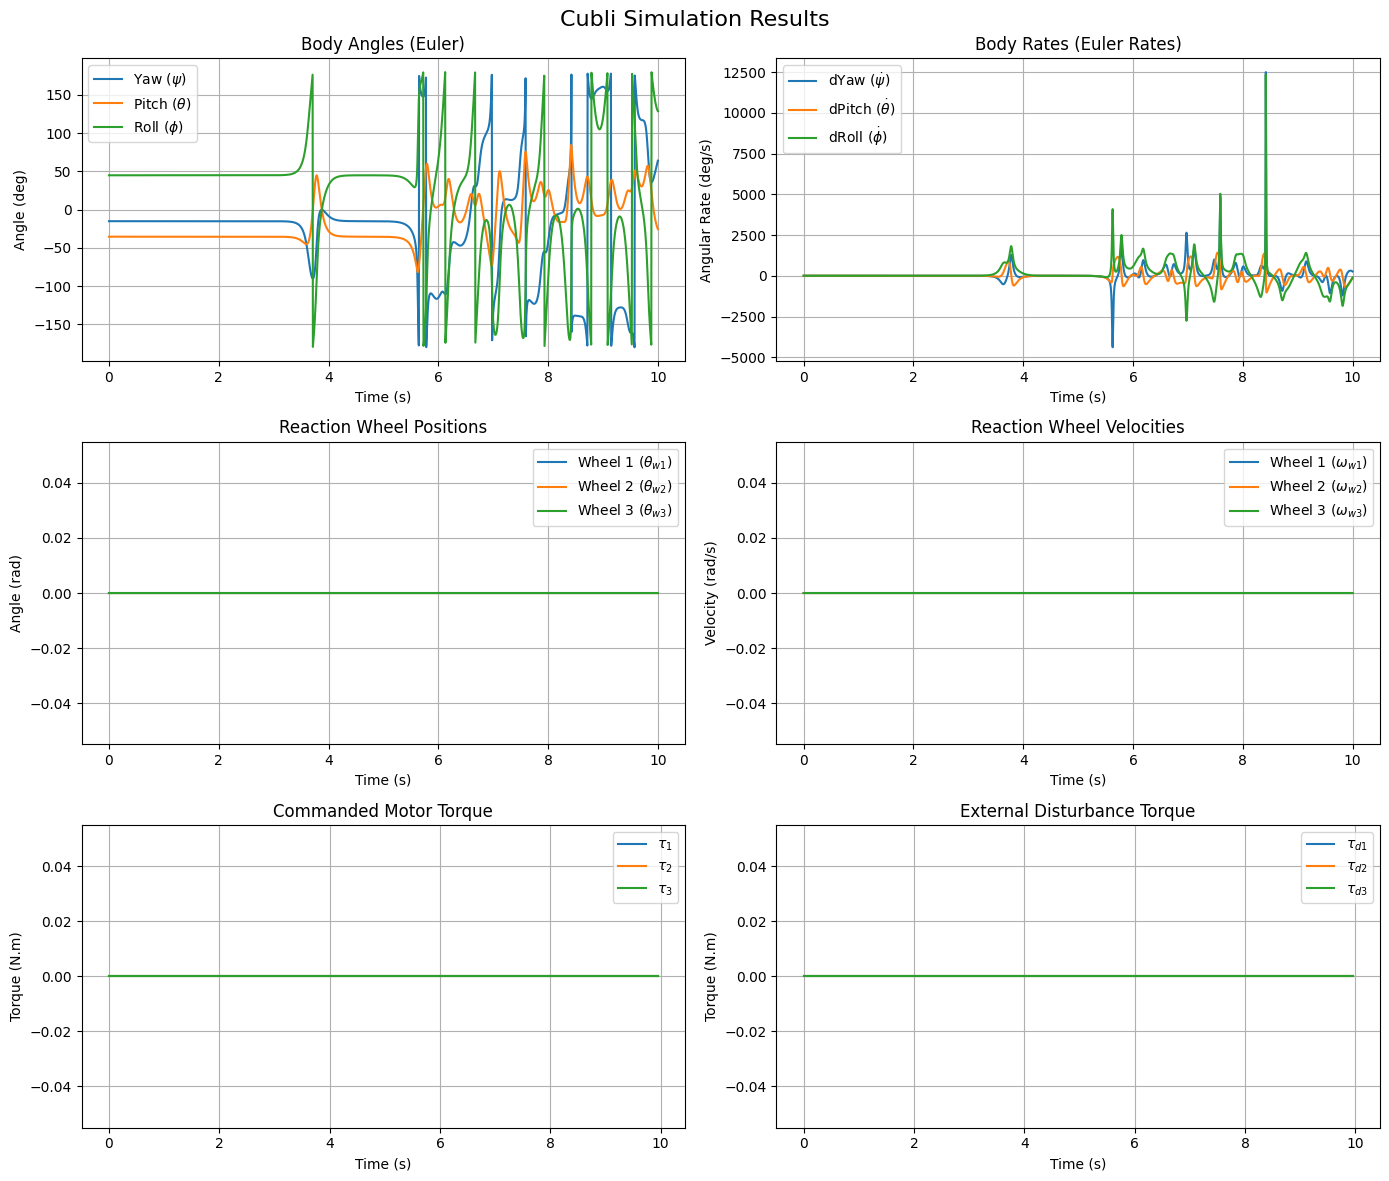

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/


Animation loaded! Use the Meshcat GUI to hit play.


In [10]:
dummy_ctrl = lambda x, t: np.zeros(3) # Just zeros for control input
x0 = np.concatenate((Q_U, np.zeros(3), np.zeros(3), np.zeros(3))) # No starting velocities
tf = 10.0 # 10 second simulation
K = 200 # 20 Hz control rate
cubli = CubliPhysics(PARAMS) # Create cubli object
sol = simulate_cubli(cubli, dummy_ctrl, x0, tf, K, None, method='RK45') # Run simulation
plot_cubli_simulation(*sol)
animate_cubli_meshcat(sol[0], sol[1])

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Unstable Equilibrium & Random Control Inputs

</div>

Completed 1/200 iterations in 0.008 sec.
Completed 2/200 iterations in 0.015 sec.
Completed 3/200 iterations in 0.021 sec.
Completed 4/200 iterations in 0.026 sec.
Completed 5/200 iterations in 0.032 sec.
Completed 6/200 iterations in 0.037 sec.
Completed 7/200 iterations in 0.042 sec.
Completed 8/200 iterations in 0.048 sec.
Completed 9/200 iterations in 0.053 sec.
Completed 10/200 iterations in 0.057 sec.
Completed 11/200 iterations in 0.063 sec.
Completed 12/200 iterations in 0.069 sec.
Completed 13/200 iterations in 0.074 sec.
Completed 14/200 iterations in 0.079 sec.
Completed 15/200 iterations in 0.084 sec.
Completed 16/200 iterations in 0.089 sec.
Completed 17/200 iterations in 0.094 sec.
Completed 18/200 iterations in 0.099 sec.
Completed 19/200 iterations in 0.103 sec.
Completed 20/200 iterations in 0.108 sec.
Completed 21/200 iterations in 0.114 sec.
Completed 22/200 iterations in 0.119 sec.
Completed 23/200 iterations in 0.125 sec.
Completed 24/200 iterations in 0.130 sec.
C

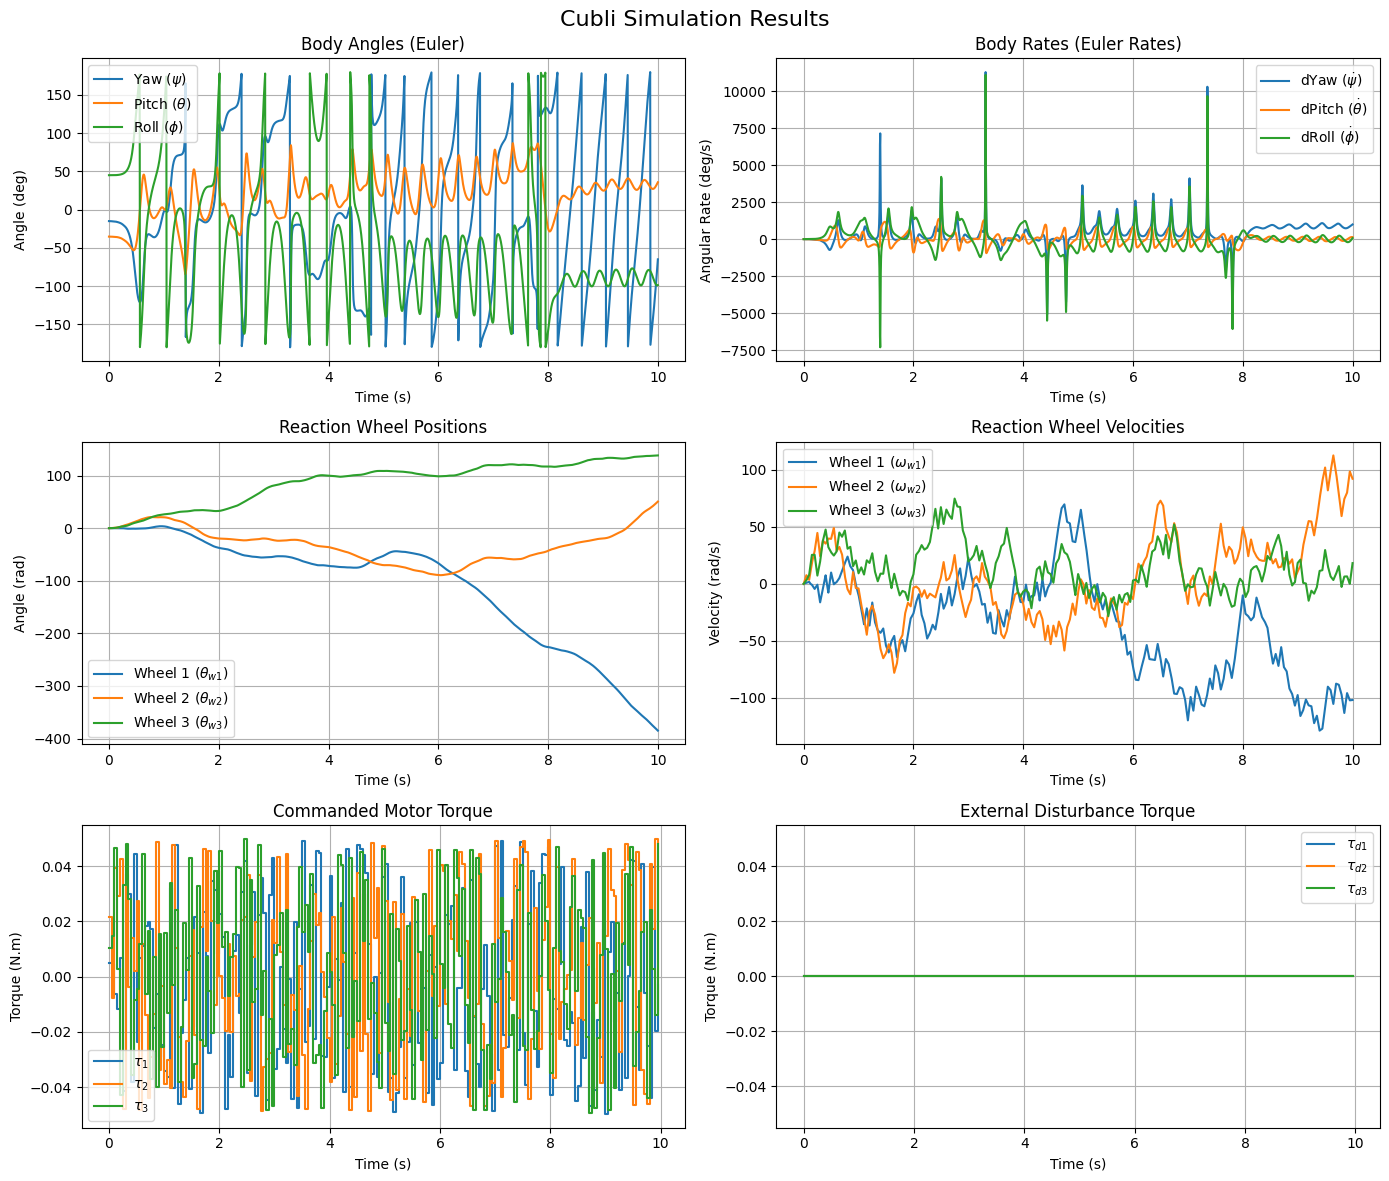

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7003/static/


Animation loaded! Use the Meshcat GUI to hit play.


In [13]:
np.random.seed(0) # Seed the random number generator for consistency 
dummy_ctrl = lambda x, t: 0.1*(np.random.random(3)-0.5) # Random control inputs [-0.05, +0.05] N.m
x0 = np.concatenate((Q_U, np.zeros(3), np.zeros(3), np.zeros(3))) # No starting velocities
tf = 10.0 # 10 second simulation
K = 200 # 20 Hz control rate
cubli = CubliPhysics(PARAMS) # Create cubli object
sol = simulate_cubli(cubli, dummy_ctrl, x0, tf, K, None, method='RK45') # Run simulation
plot_cubli_simulation(*sol)
animate_cubli_meshcat(sol[0], sol[1])

Completed 1/1200 iterations in 0.021 sec.
Completed 2/1200 iterations in 0.128 sec.
Completed 3/1200 iterations in 0.146 sec.
Completed 4/1200 iterations in 0.163 sec.
Completed 5/1200 iterations in 0.181 sec.
Completed 6/1200 iterations in 0.200 sec.
Completed 7/1200 iterations in 0.216 sec.
Completed 8/1200 iterations in 0.236 sec.
Completed 9/1200 iterations in 0.254 sec.
Completed 10/1200 iterations in 0.276 sec.
Completed 11/1200 iterations in 0.294 sec.
Completed 12/1200 iterations in 0.312 sec.
Completed 13/1200 iterations in 0.332 sec.
Completed 14/1200 iterations in 0.351 sec.
Completed 15/1200 iterations in 0.369 sec.
Completed 16/1200 iterations in 0.386 sec.
Completed 17/1200 iterations in 0.404 sec.
Completed 18/1200 iterations in 0.424 sec.
Completed 19/1200 iterations in 0.446 sec.
Completed 20/1200 iterations in 0.467 sec.
Completed 21/1200 iterations in 0.484 sec.
Completed 22/1200 iterations in 0.501 sec.
Completed 23/1200 iterations in 0.521 sec.
Completed 24/1200 it

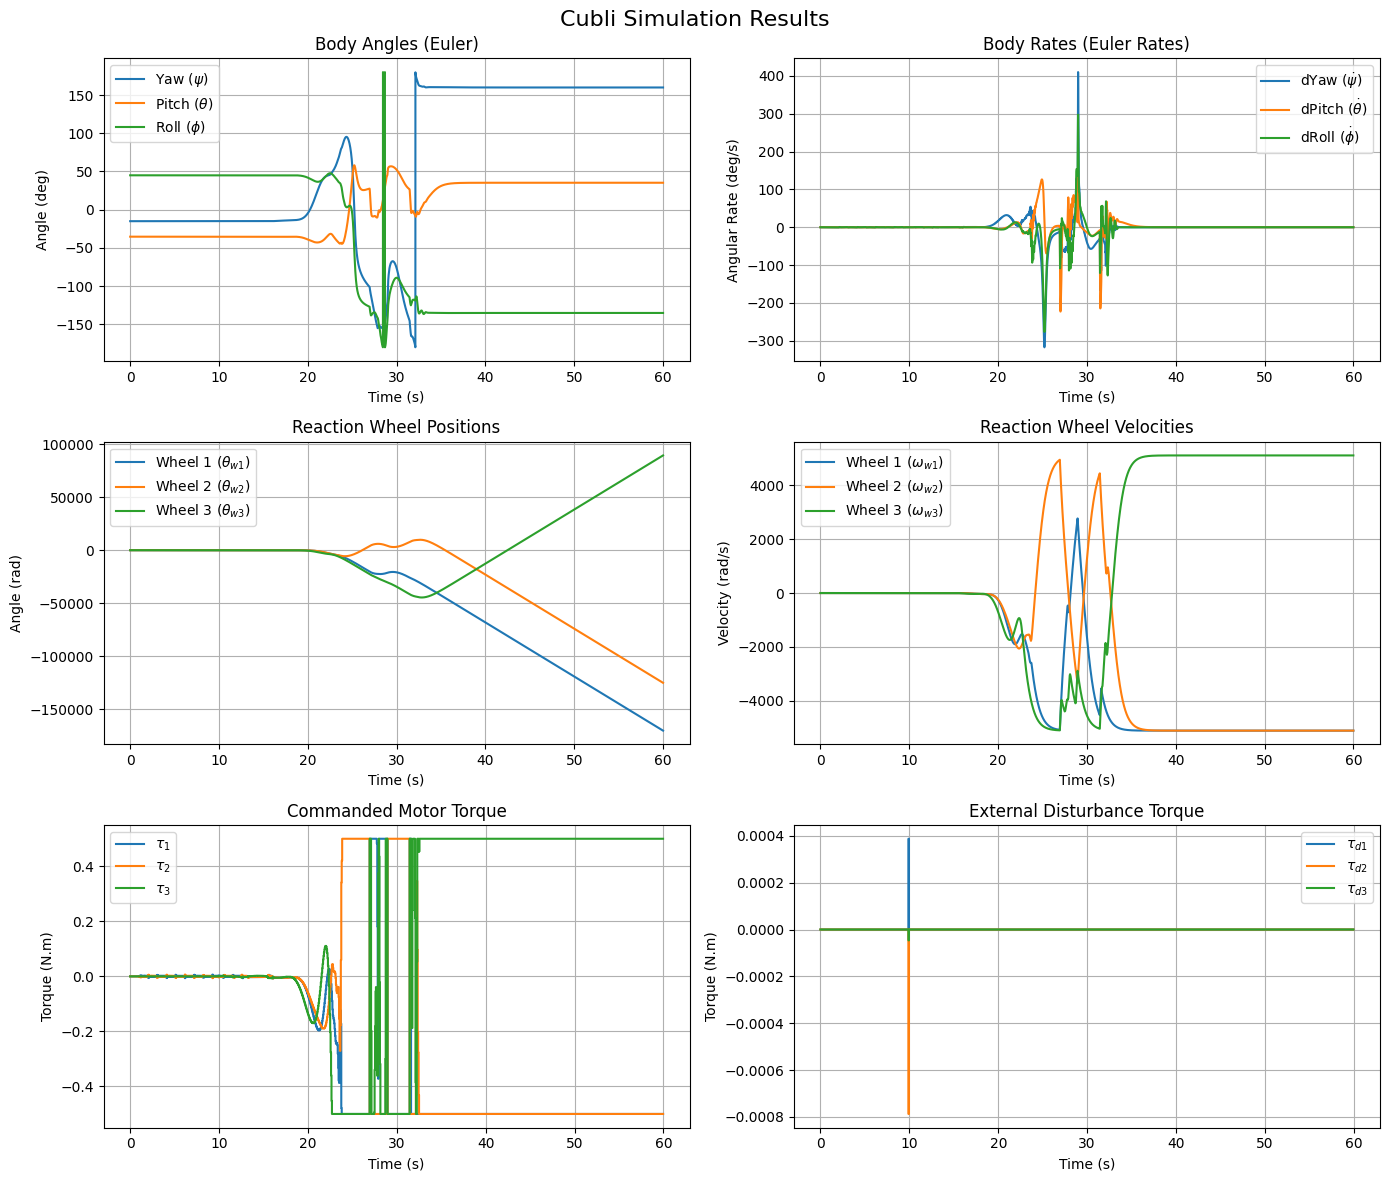

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7011/static/


Animation loaded!


In [23]:
x0 = np.concatenate((Q_U, np.zeros(3), np.zeros(3), np.zeros(3))) # No starting velocities
tf = 60.0 # 60 second simulation
K = 1200 # 20 Hz control rate
cubli = CubliPhysics(PARAMS) # Create cubli object

# Create 5 random disturbance torques [-0.5, 0.5] N.m
Nd = 1
max_d = 0.001
np.random.seed(0)
tau_d = np.zeros((K, 3))
rand_idx = np.random.choice(K, size=Nd, replace=False)
rand_tau = np.random.uniform(low=-max_d, high=max_d, size=(Nd, 3))
tau_d[rand_idx] = rand_tau

# Solve and plot
sol = simulate_cubli(cubli.ode_fun, cubli.controller_fun, x0, tf, K, tau_d, method='RK45') # Run simulation
plot_cubli_simulation(*sol)
animate_cubli_meshcat(sol[0], sol[1])